# Stock Data Overview

### Import Data

In [85]:
from pathlib import Path
import sys
import pandas as pd

# Add src as part of the import system also
sys.path.append(str(Path.cwd().parent / 'src'))

from config import RAW_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH / 'all_stocks_combined.csv')

### Sample Combined Data

In [86]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Name
0,2018-01-02,5.563982,5.575502,5.523663,5.558222,5284100,1155.KL,Maybank
1,2018-01-03,5.633101,5.633101,5.563983,5.563983,13946300,1155.KL,Maybank
2,2018-01-04,5.644619,5.656139,5.633100,5.633100,18711500,1155.KL,Maybank
3,2018-01-05,5.644619,5.656139,5.638860,5.644619,17266600,1155.KL,Maybank
4,2018-01-08,5.673418,5.673418,5.638858,5.644618,19238800,1155.KL,Maybank


### Data Info

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25107 entries, 0 to 25106
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    25107 non-null  str    
 1   Close   25107 non-null  float64
 2   High    25107 non-null  float64
 3   Low     25107 non-null  float64
 4   Open    25107 non-null  float64
 5   Volume  25107 non-null  int64  
 6   Ticker  25107 non-null  str    
 7   Name    25107 non-null  str    
dtypes: float64(4), int64(1), str(3)
memory usage: 2.2 MB


**Total we have 8 columns for raw data.**

### Check Null

In [88]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
Name      0
dtype: int64

**No null found in the columns.**

### Check Duplicates

In [89]:
df.duplicated().sum()

np.int64(0)

**No duplicates found.**

### Data Interpretation

In [90]:
df.describe()

,Close,High,Low,Open,Volume
count,25107.000000,25107.000000,25107.000000,25107.000000,2.510700e+04
mean,9.026227,9.087172,8.963334,9.024600,6.180911e+06
std,9.347332,9.399606,9.289367,9.341288,8.727439e+06
min,0.916608,0.944175,0.861474,0.895932,0.000000e+00
25%,2.916727,2.946970,2.891089,2.916727,1.323000e+06
50%,4.671149,4.703162,4.627575,4.671180,3.436000e+06
75%,14.142509,14.287067,14.011407,14.118929,7.451200e+06
max,66.290001,67.000000,66.269997,66.389999,2.236875e+08


**Closing Price**

- Has very wide range (min ~ 1, max ~ 66)
- This means that different stocks are on completely different scales, will need to do normalization
- Data is right-skewed (mean ~ 9, median ~ 5), a few high-price stocks pull the average up

**Volatility (std)**

- Prices fluctuate a lot across stocks
- Volume is highly unstable

**Volume Insight**

- Some days have no trading activity, but some days have huge spikes (min = 0, max = 2.236875e+08)
- This indicates that volume is highly non-linear

*Note:*

- *Malaysia stocks → MYR*
- *Singapore stocks → SGD*
- *No currency conversion is applied*
- *Feature engineering will use return-based features to ensure comparability across the assets*


# Representative Stock Analysis

Picking some representatives to explore individual stock data.

In [91]:
# Create subsets
maybank = df[df['Ticker'] == '1155.KL']
cimb = df[df['Ticker'] == '1023.KL']
dbs = df[df['Ticker'] == 'D05.SI']

### Sample data

In [92]:
maybank.head()

,Date,Close,High,Low,Open,Volume,Ticker,Name
0,2018-01-02,5.563982,5.575502,5.523663,5.558222,5284100,1155.KL,Maybank
1,2018-01-03,5.633101,5.633101,5.563983,5.563983,13946300,1155.KL,Maybank
2,2018-01-04,5.644619,5.656139,5.633100,5.633100,18711500,1155.KL,Maybank
3,2018-01-05,5.644619,5.656139,5.638860,5.644619,17266600,1155.KL,Maybank
4,2018-01-08,5.673418,5.673418,5.638858,5.644618,19238800,1155.KL,Maybank


In [93]:
cimb.head()

,Date,Close,High,Low,Open,Volume,Ticker,Name
4158,2018-01-02,4.290183,4.329784,4.270382,4.323184,8969000,1023.KL,CIMB Group
4159,2018-01-03,4.309984,4.342985,4.290183,4.316584,24822600,1023.KL,CIMB Group
4160,2018-01-04,4.323184,4.329785,4.296783,4.316584,30095900,1023.KL,CIMB Group
4161,2018-01-05,4.422188,4.422188,4.329784,4.329784,35194800,1023.KL,CIMB Group
4162,2018-01-08,4.501392,4.507992,4.375987,4.422189,29909700,1023.KL,CIMB Group


In [94]:
dbs.head()

,Date,Close,High,Low,Open,Volume,Ticker,Name
18708,2018-01-02,14.521714,14.521714,14.343074,14.360362,3155680,D05.SI,DBS Bank
18709,2018-01-03,14.913571,14.925097,14.521716,14.521716,5108070,D05.SI,DBS Bank
18710,2018-01-04,15.270854,15.270854,14.873236,14.982724,6269670,D05.SI,DBS Bank
18711,2018-01-05,15.167127,15.316953,15.069162,15.167127,4527820,D05.SI,DBS Bank
18712,2018-01-08,15.242036,15.247798,15.121022,15.172885,2881450,D05.SI,DBS Bank


### Data Interpretation

In [95]:
pd.DataFrame({ "Maybank": maybank['Close'].describe(), "CIMB": cimb['Close'].describe(), "DBS": dbs['Close'].describe()})

,Maybank,CIMB,DBS
count,2079.000000,2079.000000,2133.000000
mean,7.149869,4.724249,26.030417
std,1.767174,1.573034,12.573231
min,4.606914,2.152782,10.911594
25%,5.716389,3.646840,16.278805
50%,6.725913,4.182673,22.893360
75%,8.793019,5.983958,31.267620
max,12.033780,8.722335,66.290001


**Closing Price**

- Stocks are confirmed to have very different scales
- Cannot directly compare raw prices

**Volatility**

- Some stocks move slowly (stable), some stocks are moving more aggressive

### Visualization

**Raw:**

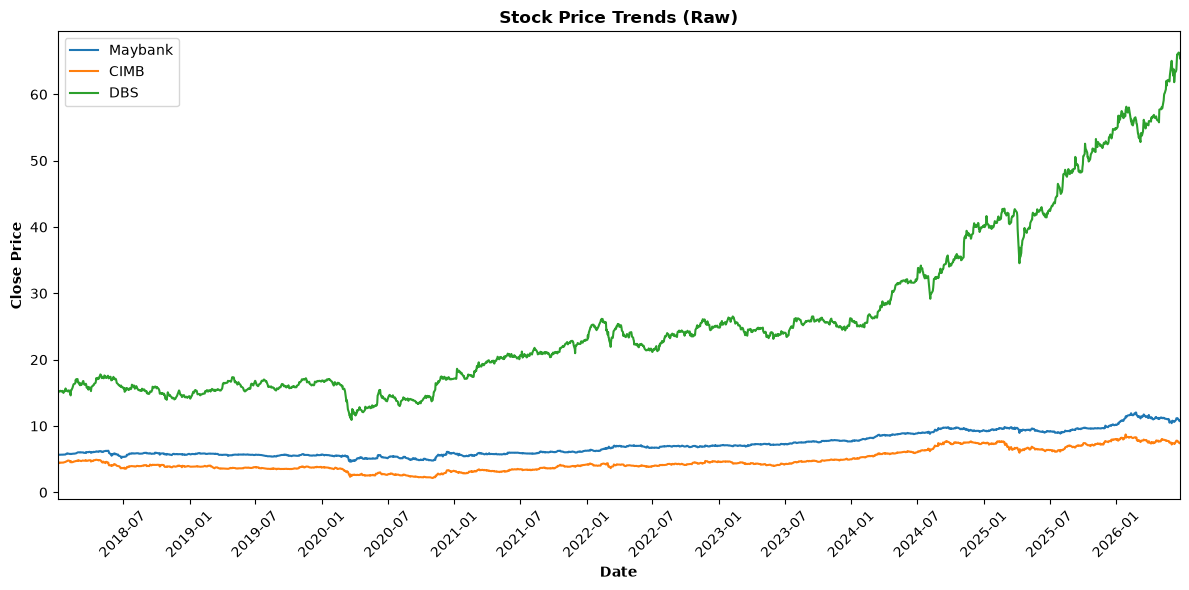

In [96]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure datetime
maybank['Date'] = pd.to_datetime(maybank['Date'])
cimb['Date'] = pd.to_datetime(cimb['Date'])
dbs['Date'] = pd.to_datetime(dbs['Date'])

plt.figure(figsize = (12,6))

plt.plot(maybank['Date'], maybank['Close'], label = 'Maybank')
plt.plot(cimb['Date'], cimb['Close'], label = 'CIMB')
plt.plot(dbs['Date'], dbs['Close'], label = 'DBS')

plt.title("Stock Price Trends (Raw)", fontweight = 'bold')
plt.xlabel("Date", fontweight = 'bold')
plt.ylabel("Close Price", fontweight = 'bold')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 6))  # every 6 months

plt.xlim(maybank['Date'].min(), maybank['Date'].max()) # restricting the range

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Normalized:**

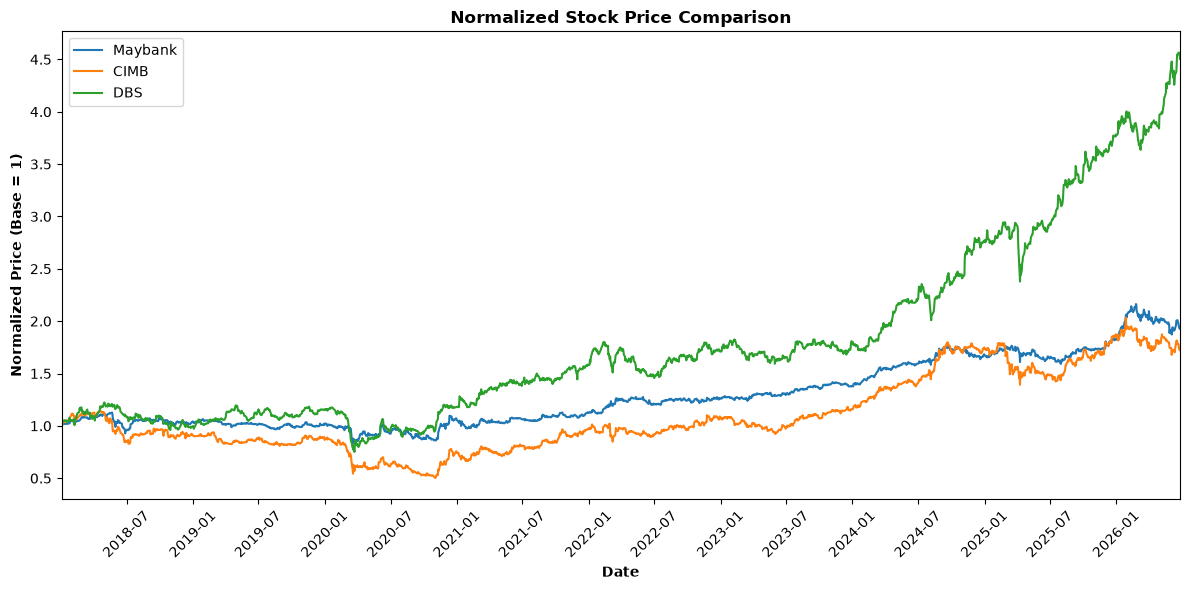

In [97]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure datetime
maybank['Date'] = pd.to_datetime(maybank['Date'])
cimb['Date'] = pd.to_datetime(cimb['Date'])
dbs['Date'] = pd.to_datetime(dbs['Date'])

# Normalize (base = 1 at start)
maybank_norm = maybank['Close'] / maybank['Close'].iloc[0]
cimb_norm = cimb['Close'] / cimb['Close'].iloc[0]
dbs_norm = dbs['Close'] / dbs['Close'].iloc[0]

plt.figure(figsize = (12,6))

plt.plot(maybank['Date'], maybank_norm, label = 'Maybank')
plt.plot(cimb['Date'], cimb_norm, label = 'CIMB')
plt.plot(dbs['Date'], dbs_norm, label = 'DBS')

plt.title("Normalized Stock Price Comparison", fontweight='bold')
plt.xlabel("Date", fontweight='bold')
plt.ylabel("Normalized Price (Base = 1)", fontweight='bold')

plt.legend()


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 6)) # every 6 months

plt.xlim(maybank['Date'].min(), maybank['Date'].max()) # restricting the range

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Prices are normalized by dividing each stock's closing price by its first value to create a comparable growth index across different stocks.** (to remove the scale differences)

- 1 represents the starting price
- Values above 1 indicate growth
- Values below 1 indicate decline